# 01 - The PPO Expert
### Reinforcement Learning & Autonomous Systems - Group Project (Imitation Learning half)

**Project framing.** The assignment is *PPO + Imitation Learning* (Behavioural Cloning and DAgger). With Jaume's approval we run the **same pipeline in 1v1 Rocket League** (`rlgym_sim` + `rlgym-ppo`) instead of Walker2D / Ant. The structure of the rubric is unchanged:

| Rubric element | Our realisation |
|---|---|
| PPO expert | Our champion 1v1 bot, trained with PPO self-play (~3.4B steps) |
| Expert demonstrations | `(observation, action)` pairs rolled out from the champion |
| Behavioural Cloning | A from-scratch MLP trained by supervised learning (notebook 03) |
| DAgger | Student rollout -> expert relabelling -> aggregate -> retrain (notebook 04) |
| Ablations | Dataset size + network capacity (notebook 03) |
| Expert vs student video | Rendered head-to-head match (notebook 04) |

**Why this is a classification problem.** The action space is the **90-way discrete `LookupAction`** (each index = a controller vector). So cloning the expert is a *classification* task with **cross-entropy** loss over 90 classes - **not** MSE regression. This is the single most important modelling decision in the whole pipeline.

**The expert is a black box.** We only ever *call* the champion to choose an action or to label a state. We never read its weights or training recipe - exactly how DAgger treats its expert oracle.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # make imitation/ importable -> il_core (cwd = notebooks/)
import il_core
il_core.use_repo_cwd()                       # chdir to repo root so RocketSim finds ./collision_meshes/
import numpy as np
import torch
import matplotlib.pyplot as plt
from il_core import (ExpertPolicy, BCStudent, DemoBuffer, collect_expert_demos,
                     train_bc, rollout_student_relabel, evaluate_student_winrate,
                     save_student_checkpoint, build_env, OBS_DIM, N_ACTIONS,
                     EXPERT_CKPT, DATA_DIR, ARTIFACT_DIR, REPO_ROOT)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('engine loaded | OBS_DIM', OBS_DIM, '| N_ACTIONS', N_ACTIONS)

engine loaded | OBS_DIM 107 | N_ACTIONS 90


## Load the expert and inspect it
The champion is a `DiscreteFF` policy: `AdvancedObs` (107-dim) in, a softmax over 90 actions out. We wrap it in `ExpertPolicy`, exposing only `.act()` (chosen action) and `.action_probs()` (full distribution, for diagnostics).

In [2]:
expert = ExpertPolicy(device='cpu')
print('Expert loaded from:', EXPERT_CKPT)
print('Hidden layers (inferred from weights):',
      [tuple(m.weight.shape) for m in expert.policy.model if hasattr(m, 'weight')])

Expert loaded from: C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group Project\rlgym\martin-bots\checkpoints\CHAMPION_3.37B_advanced1024
Hidden layers (inferred from weights): [(1024, 107), (1024, 1024), (1024, 1024), (90, 1024)]


### The expert acting on a real game state
We reset a 1v1 env, take the blue car's observation, and show the expert's chosen action plus its top-5 action probabilities. A peaked distribution means a confident expert - good news for cloning.

obs shape       : (107,)
chosen action   : 18
top-5 actions   : [18, 73, 39, 71, 53]
their probs     : [0.02, 0.018, 0.017, 0.017, 0.017]


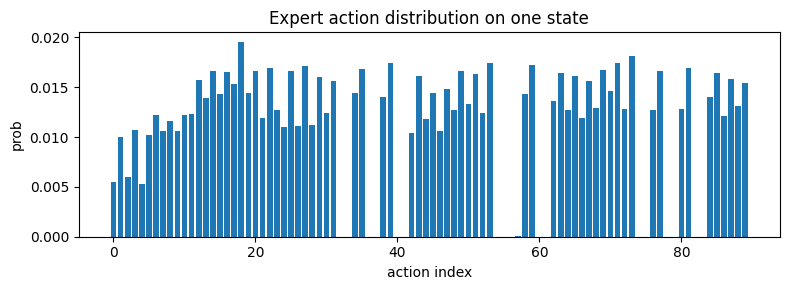

In [3]:
env = build_env(max_seconds=10, randomize=False)
obs, info = env.reset(return_info=True)
obs0 = (obs if isinstance(obs, list) else [obs])[0]
a = expert.act(obs0, deterministic=True)
probs = expert.action_probs(obs0)
top5 = np.argsort(probs)[::-1][:5]
print('obs shape       :', np.asarray(obs0).shape)
print('chosen action   :', a)
print('top-5 actions   :', list(top5))
print('their probs     :', [round(float(probs[i]), 3) for i in top5])
env.close()

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(N_ACTIONS), probs)
ax.set_title('Expert action distribution on one state'); ax.set_xlabel('action index'); ax.set_ylabel('prob')
plt.tight_layout(); plt.show()

**Takeaway.** The expert is loaded and behaves deterministically (argmax) as deployed. Notebook **02** turns it into a demonstration dataset; **03** clones it with BC; **04** improves the clone with DAgger and renders an expert-vs-student match.